# Team Stats, Registry, and Pythagorean Expectation

NCAA team statistics for Divisions I-III, 2002-2026, the canonical team
registry that lets every dataset join, and the Pythagorean expectation built on
top of them.

Covers: `get_team_stat`, `display_specific_team_stat`, `display_team_stats`,
`list_all_teams`, `plot_team_stat_over_years`, `average_all_team_stats`,
`average_team_stat_str`, `average_team_stat_float`, `resolve_team`,
`resolve_team_verbose`, `team_info`, `team_aliases`, `team_seasons`,
`team_division`, `team_conference`, `list_teams`, `list_conferences`,
`crosswalk`, `get_pythagorean_expectation`, `compare_pythagorean_expectation`,
`pythagorean_exponent`, `conference_exponents`, `luck_rating`,
`luckiest_teams`, `unluckiest_teams`

In [1]:
%matplotlib inline
from ncaa_bbStats import *

## Reading a team's season

In [2]:
# A single statistic
print("Northeastern 2025 HR:", get_team_stat("HR", "Northeastern", 2025, 1))
print("Northeastern 2025 ERA:", get_team_stat("ERA", "Northeastern", 2025, 1))

# Team names match on a case-insensitive substring
display_specific_team_stat("WPCT", "Northeastern", 2025, 1)

Northeastern 2025 HR: 77
Northeastern 2025 ERA: 3.06
Northeastern (CAA) - WPCT: 0.817


In [3]:
# Everything the cache holds for one team
display_team_stats("Northeastern", 2025, 1)


Stats for Northeastern (CAA):
  team: Northeastern
  league: CAA
  W: 49
  L: 11
  T: 0
  WPCT: 0.817
  G: 60
  BB (Batting): 266
  AB: 1969
  H: 559
  BA: 0.284
  DP: 35
  DPPG: 0.58
  2B: 105
  2BPG: 1.75
  IP: 523.0
  R (Pitching): 205
  ER: 178
  ERA: 3.06
  PO: 1569
  A: 596
  E: 44
  FPCT: 0.98
  HB: 47
  HBP: 76
  HA: 417
  HAPG: 7.18
  HR: 77
  HRPG: 1.28
  SF: 28
  SH: 22
  OBP: 0.385
  SB: 196
  CS: 46
  R (Batting): 441
  RPG: 7.4
  SHO: 17
  TB: 915
  SLG: 0.465
  SBPG: 3.27
  SO: 491
  BB (Pitching): 142
  K/BB: 3.46
  K/9: 8.4
  3B: 10
  3BPG: 0.17
  WHIP: 1.07
  BBPG (Pitching): 2.44


In [4]:
# Who is in a division that season? Labels are "Team Name (Conference)".
teams = list_all_teams(2025, 1)
print(f"{len(teams)} Division I teams in 2025")
print(teams[:5])

print(f"\n{len(list_all_teams(2025, 2))} Division II, "
      f"{len(list_all_teams(2025, 3))} Division III")

299 Division I teams in 2025
['Northeastern (CAA)', 'Coastal Carolina (Sun Belt)', 'LSU (SEC)', 'Arkansas (SEC)', 'Western Ky. (CUSA)']

247 Division II, 379 Division III


## League averages

In [5]:
averages = average_all_team_stats(2025, 1)
print(f"{len(averages)} averaged statistics")
for key in ["BA", "ERA", "HR", "WHIP", "FPCT"]:
    print(f"  {key:6s} {averages[key]}")

47 averaged statistics
  BA     0.28
  ERA    6.274
  HR     59.361
  WHIP   1.65
  FPCT   0.968


In [6]:
print(average_team_stat_str("HR", 2025, 1))
print("as a float:", average_team_stat_float("HR", 2025, 1))

# Division III plays in a different run environment
print(average_team_stat_str("ERA", 2025, 1))
print(average_team_stat_str("ERA", 2025, 3))

Avg HR for Division 1 in 2025: 59.361
as a float: 59.361
Avg ERA for Division 1 in 2025: 6.274
Avg ERA for Division 3 in 2025: 6.491


## Plotting a statistic over time

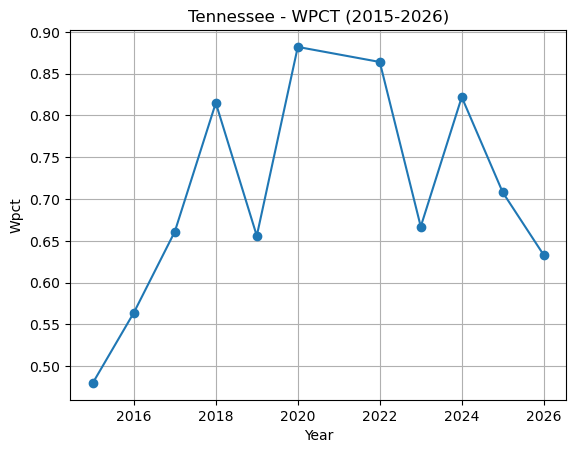

In [7]:
plot_team_stat_over_years("WPCT", "Tennessee", 1, 2015, 2026)

## The team registry

Each source spells schools differently. The registry maps them all onto one
`team_id`, which is what lets the datasets join.

In [8]:
# Four spellings, one program
for name in ["Eastern Ill.", "EIU", "Eastern Illinois", "Eastern Illinois University"]:
    print(f"  {name:32s} -> {resolve_team(name)}")

  Eastern Ill.                     -> IPEDS:144892
  EIU                              -> IPEDS:144892
  Eastern Illinois                 -> IPEDS:144892
  Eastern Illinois University      -> IPEDS:144892


In [9]:
# resolve_team_verbose says how the match was made
print(resolve_team_verbose("Alabama State"))
print(resolve_team_verbose("EIU"))

# There is no fuzzy fallback: an unknown name returns None rather than a guess
print("unknown ->", resolve_team("Not A Real School"))

Resolution(team_id='IPEDS:100724', matched_alias='Alabama State', namespace='rpi', method='exact')
Resolution(team_id='IPEDS:144892', matched_alias='EIU', namespace='fg_acronym', method='exact')
unknown -> None


In [10]:
# Rebrands keep one identity, so a program's history stays joined
print("Dixie State == Utah Tech      :",
      resolve_team("Dixie State") == resolve_team("Utah Tech"))
print("Houston Baptist == Houston Christian:",
      resolve_team("Houston Baptist") == resolve_team("Houston Christian"))

# Schools distinguished only by state stay separate
print("Miami (OH) != Miami (FL)      :",
      resolve_team("Miami (OH)") != resolve_team("Miami (FL)"))

Dixie State == Utah Tech      : True
Houston Baptist == Houston Christian: True
Miami (OH) != Miami (FL)      : True


In [11]:
import json
print(json.dumps(team_info("Northeastern", season=2025), indent=2))

{
  "team_id": "IPEDS:167358",
  "canonical_name": "Northeastern",
  "ipeds_unitid": "167358",
  "institution_name": "Northeastern University",
  "state": "MA",
  "id_source": "ipeds",
  "first_season": 2002,
  "last_season": 2026,
  "divisions": [
    1
  ],
  "season": 2025,
  "division": 1,
  "conference": "CAA"
}


In [12]:
# Every known spelling of a program, or just one source's
print("all aliases:", team_aliases("Northeastern")[:8])
print("as the player cache spells it:", team_aliases("Northeastern", "fg_acronym"))

all aliases: ['NE', 'Northeastern', 'Northeastern (America East)', 'Northeastern (CAA)', 'Northeastern University']
as the player cache spells it: ['NE']


In [13]:
# Division is a season attribute, not part of identity: Utah Tech moved up
for row in team_seasons("Utah Tech"):
    if row["season"] >= 2019:
        print(f"  {row['season']}  D{row['division']}  {row['conference']}")

  2019  D2  RMAC
  2020  D2  RMAC
  2025  D1  WAC
  2026  D1  WAC


In [14]:
print("Utah Tech division in 2015:", team_division("Utah Tech", 2015))
print("Utah Tech division in 2026:", team_division("Utah Tech", 2026))
print("Northeastern conference 2025:", team_conference("Northeastern", 2025))

Utah Tech division in 2015: 2
Utah Tech division in 2026: 1
Northeastern conference 2025: CAA


In [15]:
sec = list_teams(season=2025, conference="SEC")
print(f"{len(sec)} SEC programs:", [t["canonical_name"] for t in sec][:8])

print(f"\n{len(list_conferences(2025, 1))} Division I conferences in 2025")
print(list_conferences(2025, 1)[:10])

16 SEC programs: ['Alabama', 'Arkansas', 'Auburn', 'Florida', 'Georgia', 'Kentucky', 'LSU', 'Mississippi St.']

30 Division I conferences in 2025
['ACC', 'ASUN', 'America East', 'Atlantic 10', 'Big 12', 'Big East', 'Big South', 'Big Ten', 'Big West', 'CAA']


In [16]:
# Bulk-map one source's spellings onto another's
mapping = crosswalk("fg_acronym", "rpi", season=2025)
print(f"{len(mapping)} acronym -> RPI-name mappings")
for acronym in ["AUB", "ALST", "LSU"]:
    print(f"  {acronym:6s} -> {mapping.get(acronym)}")

307 acronym -> RPI-name mappings
  AUB    -> Auburn
  ALST   -> Alabama State
  LSU    -> LSU


## Pythagorean expectation

What a team's record *should* have been, given the runs it scored and allowed.
A team well above its expectation won more close games than its run
differential justifies, which historically does not repeat.

In [17]:
print("Northeastern 2018 expected win%:",
      get_pythagorean_expectation("Northeastern", 2018, 1))
print(compare_pythagorean_expectation("Northeastern", 2018, 1))

# The exponent can be overridden
print("with exponent 2.0:",
      get_pythagorean_expectation("Northeastern", 2018, 1, exponent=2.0))

Northeastern 2018 expected win%: 0.546
Pythagorean Expected Win% for Northeastern (2018, Div 1): 0.546 | Actual Win%: 0.632
with exponent 2.0: 0.551


In [18]:
# Conference-fitted exponents ship but are EXPERIMENTAL and not the default:
# none of the 31 differs from 1.83 at p < 0.05.
print("default exponent:", pythagorean_exponent())
print("SEC-fitted      :", pythagorean_exponent("SEC"))

rows = conference_exponents()
print(f"\n{len(rows)} conferences fitted; "
      f"{sum(1 for r in rows if r['significant'] == 'yes')} statistically significant")
for row in rows[:5]:
    print(f"  {row['conference']:16s} exp {row['exponent']:.3f}  "
          f"p={row['p_value']:.3f}  significant={row['significant']}")

default exponent: 1.83
SEC-fitted      : 1.7044

31 conferences fitted; 0 statistically significant
  MVC              exp 2.075  p=0.181  significant=no
  OVC              exp 1.979  p=0.628  significant=no
  NEC              exp 1.978  p=0.571  significant=no
  Summit League    exp 1.971  p=0.582  significant=no
  Big West         exp 1.924  p=0.527  significant=no


In [19]:
print(luck_rating("Northeastern", 2025))

{'team': 'Northeastern', 'year': 2025, 'expected_win_pct': 0.802, 'actual_win_pct': 0.8167, 'luck': 0.0147, 'luck_wins': 0.88, 'games': 60}


In [20]:
print("Outperformed their run differential most, D-I 2025:")
for row in luckiest_teams(2025, n=5):
    print(f"  {row['team']:20s} {row['conference']:10s} "
          f"actual {row['actual_win_pct']:.3f} vs expected "
          f"{row['expected_win_pct']:.3f}  ({row['luck_wins']:+.1f} wins)")

print("\nUnderperformed most:")
for row in unluckiest_teams(2025, n=5):
    print(f"  {row['team']:20s} {row['conference']:10s} "
          f"actual {row['actual_win_pct']:.3f} vs expected "
          f"{row['expected_win_pct']:.3f}  ({row['luck_wins']:+.1f} wins)")

Outperformed their run differential most, D-I 2025:
  The Citadel          SoCon      actual 0.544 vs expected 0.414  (+7.4 wins)
  Clemson              ACC        actual 0.714 vs expected 0.600  (+7.2 wins)
  Rider                MAAC       actual 0.654 vs expected 0.518  (+7.1 wins)
  Bowling Green        MAC        actual 0.600 vs expected 0.479  (+6.6 wins)
  Arizona              Big 12     actual 0.677 vs expected 0.594  (+5.4 wins)

Underperformed most:
  UCF                  Big 12     actual 0.527 vs expected 0.687  (-8.8 wins)
  Texas A&M            SEC        actual 0.536 vs expected 0.689  (-8.6 wins)
  Iowa                 Big Ten    actual 0.589 vs expected 0.720  (-7.3 wins)
  Norfolk St.          NEC        actual 0.095 vs expected 0.245  (-6.3 wins)
  Samford              SoCon      actual 0.526 vs expected 0.633  (-6.1 wins)
